# Analyze sample splitting data

In [20]:
import os
import sys
from pathlib import Path

ROOT = Path.cwd().parent
SRC = ROOT / "src"
sys.path.insert(0, str(SRC))

import time
import numpy as np
import matplotlib.pyplot as plt
import scipy
import pandas as pd
import seaborn as sns
from helpers.sample import make_sample, stopping_time

In [26]:
# load data
summary_results = pd.read_csv(ROOT / "data" / "sample_split_summary.csv")

In [27]:
summary_results
subset = summary_results[summary_results["alpha"] == 0.05]
subset

,theta,N,alpha,lambda,psi,mean_theta_hat,sd_theta_hat,mean_b_hat,sd_b_hat,power,sd_outer_power,mean_seq_stopping_time,mean_total_stopping_time,mean_total_stopping_fraction,early_stop_prob,n_outer_success,n_inner_success
15,0.05,1000,0.05,0.25,0.10,0.034639,0.112795,0.408205,0.387223,0.216873,0.194356,476.374938,576.374938,0.576375,0.686352,403,4030
16,0.05,1000,0.05,0.25,0.25,0.025124,0.067490,0.236450,0.330081,0.149324,0.155573,264.746284,514.746284,0.514746,0.786149,296,2960
17,0.05,1000,0.05,0.25,0.50,0.009135,0.029015,0.109516,0.187577,0.085398,0.109581,113.327876,613.327876,0.613328,0.853540,226,2260
18,0.05,1000,0.05,0.25,0.75,0.008131,0.015953,0.088879,0.169629,0.064602,0.077828,52.400000,802.400000,0.802400,0.846018,113,1130
19,0.05,1000,0.05,0.25,0.90,-0.001312,0.013002,0.209312,0.267466,0.070115,0.085065,40.042529,940.042529,0.940043,0.657471,87,870
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
406,1.00,50000,0.05,0.50,0.50,1.000038,0.006111,0.505243,0.000032,0.509600,0.163956,263.035800,25263.035800,0.505261,1.000000,500,5000
407,1.00,50000,0.05,0.50,0.75,0.999955,0.005415,0.755224,0.000028,0.759800,0.136973,261.243800,37761.243800,0.755225,1.000000,500,5000
408,1.00,50000,0.05,0.50,0.90,0.999866,0.004786,0.904173,0.000020,0.908000,0.092049,207.334800,45207.334800,0.904147,1.000000,500,5000
409,1.00,50000,0.05,0.75,0.75,0.999854,0.004935,0.256650,0.000034,0.253000,0.141319,112.165000,37612.165000,0.752243,1.000000,500,5000


In [29]:
# check specific scenarios
def check_scenario(theta, psi, lambda_):
    return subset[
        (subset["theta"] == theta)
        & (subset["psi"] == psi)
        # & (subset["N"] == N)
        & (subset["lambda"] == lambda_)
    ]

check_scenario(theta = 1, psi = 0.5, lambda_ = 0.5)

,theta,N,alpha,lambda,psi,mean_theta_hat,sd_theta_hat,mean_b_hat,sd_b_hat,power,sd_outer_power,mean_seq_stopping_time,mean_total_stopping_time,mean_total_stopping_fraction,early_stop_prob,n_outer_success,n_inner_success
334,1.0,1000,0.05,0.5,0.5,0.998568,0.043330,0.539110,0.001821,0.5604,0.163846,39.6704,539.6704,0.539670,1.0,500,5000
358,1.0,5000,0.05,0.5,0.5,0.999491,0.019607,0.516887,0.000340,0.5340,0.157396,85.2640,2585.2640,0.517053,1.0,500,5000
382,1.0,10000,0.05,0.5,0.5,0.999577,0.013867,0.511848,0.000168,0.5072,0.158614,119.2264,5119.2264,0.511923,1.0,500,5000
406,1.0,50000,0.05,0.5,0.5,1.000038,0.006111,0.505243,0.000032,0.5096,0.163956,263.0358,25263.0358,0.505261,1.0,500,5000


## Analyze $\hat b$

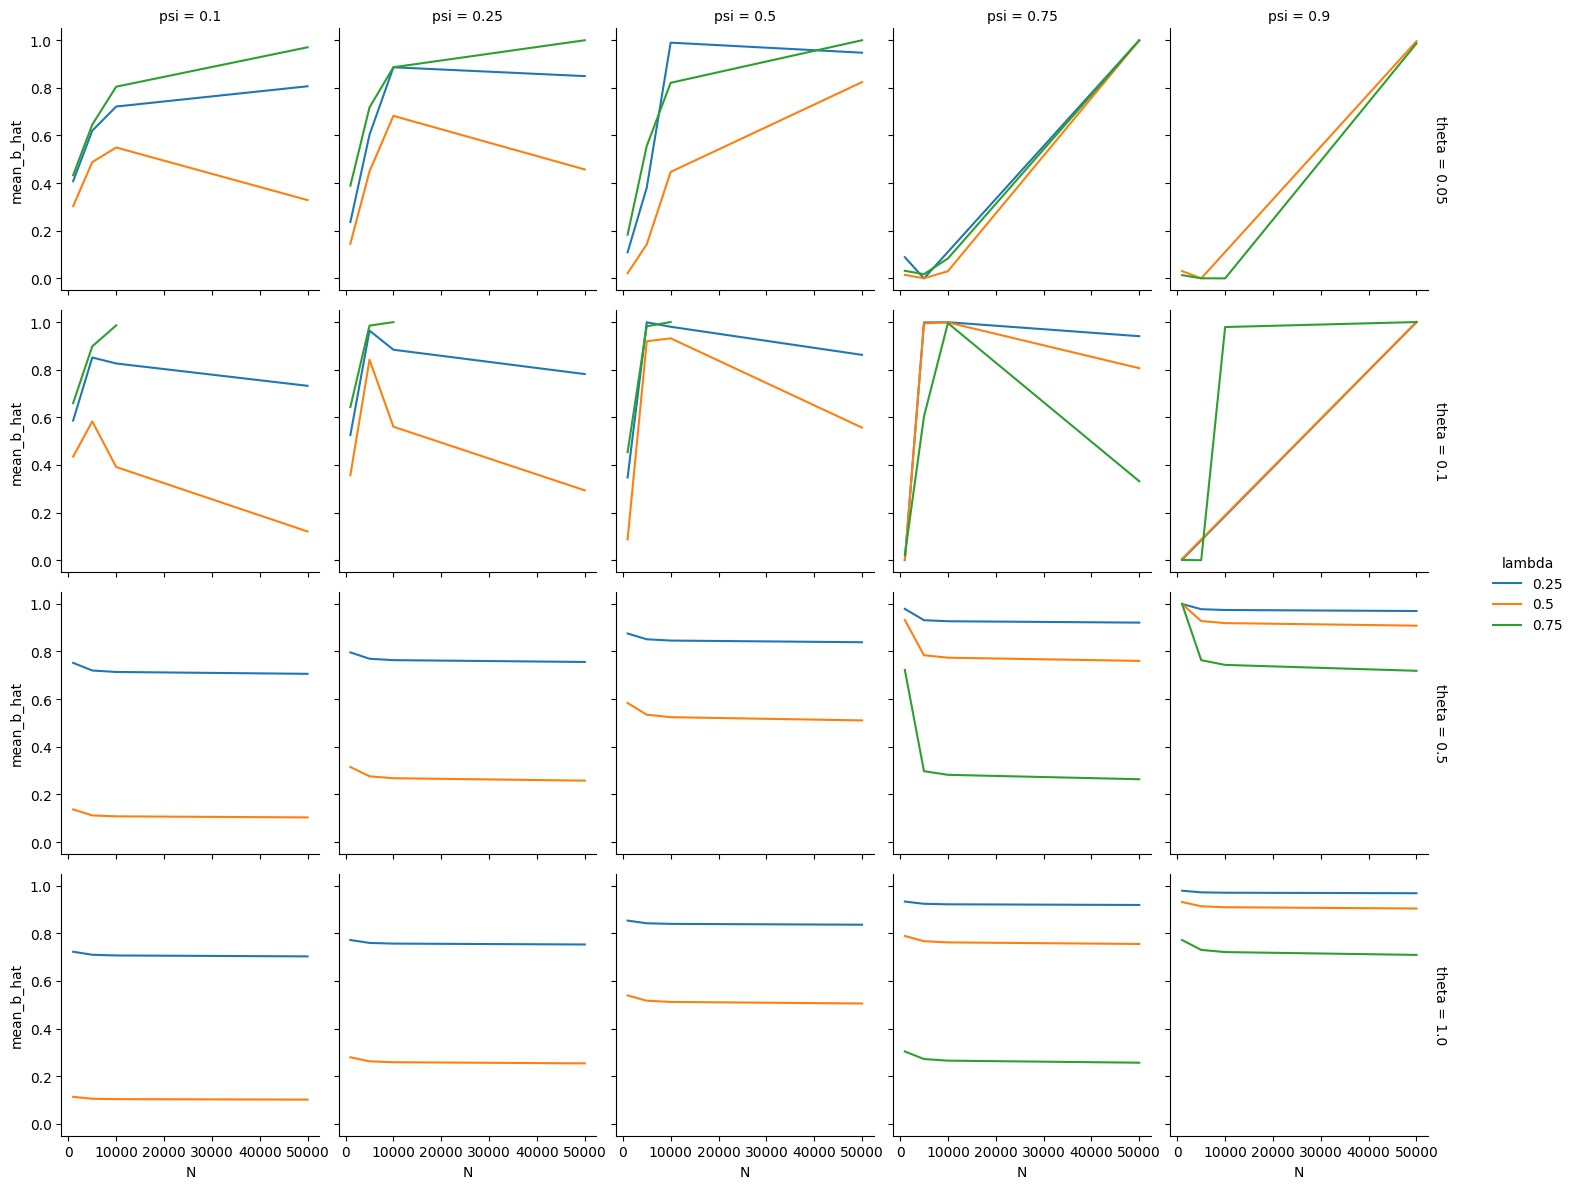

In [23]:
# make a plot of mean_b_hat by theta for different values of psi, N, and lambda
# the plot should have N on the x-axis, mean_b_hat on the y_axis. Different lines should represent \psi. The columns should be different values of lambda and the rows should be different values of theta. Each plot should have a title indicating the value of theta. first subset only alpha = 0.05

# plot mean_b_hat by theta for different values of psi, N, and lambda
g = sns.FacetGrid(subset, col="psi", row="theta", hue="lambda", margin_titles=True, sharey=True)
g.map(sns.lineplot, "N", "mean_b_hat")
g.add_legend()